In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ai4i2020.csv")

In [19]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [10]:
df.shape

(10000, 14)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [13]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [14]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [15]:
df['Machine failure'].mean() * 100

np.float64(3.39)

In [16]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df[failure_types].sum()

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64

In [20]:
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

df[failure_types].sum(axis=1).value_counts().sort_index()

0    9652
1     324
2      23
3       1
Name: count, dtype: int64

In [21]:
df.loc[
    df[failure_types].sum(axis=1) > 1,
    ['Machine failure'] + failure_types
].head(10)

,Machine failure,TWF,HDF,PWF,OSF,RNF
69,1,0,0,1,1,0
1324,1,0,0,1,1,0
1496,1,0,0,1,1,0
3611,1,1,0,0,0,1
3854,1,0,0,1,1,0
3943,1,0,0,1,1,0
4254,1,0,1,1,0,0
4342,1,0,1,1,0,0
4370,1,0,1,0,1,0
4383,1,0,1,0,1,0


In [22]:
TARGET = "Machine failure"

FAILURE_COLUMNS = [
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

IDENTIFIER_COLUMNS = [
    "UDI",
    "Product ID",
]


In [23]:
failure_counts = (
    df[TARGET]
    .value_counts()
    .sort_index()
)

failure_percentages = (
    df[TARGET]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

target_distribution = pd.DataFrame({
    "count": failure_counts,
    "percentage": failure_percentages
})

target_distribution.index = [
    "No failure",
    "Machine failure",
]

display(target_distribution)


,count,percentage
No failure,9661,96.61
Machine failure,339,3.39


In [24]:
import seaborn as sns

In [27]:
import matplotlib.pyplot as plt

/var/folders/zd/fp054_g97jj0r41dl9w08k940000gn/T/ipykernel_23816/3794594028.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


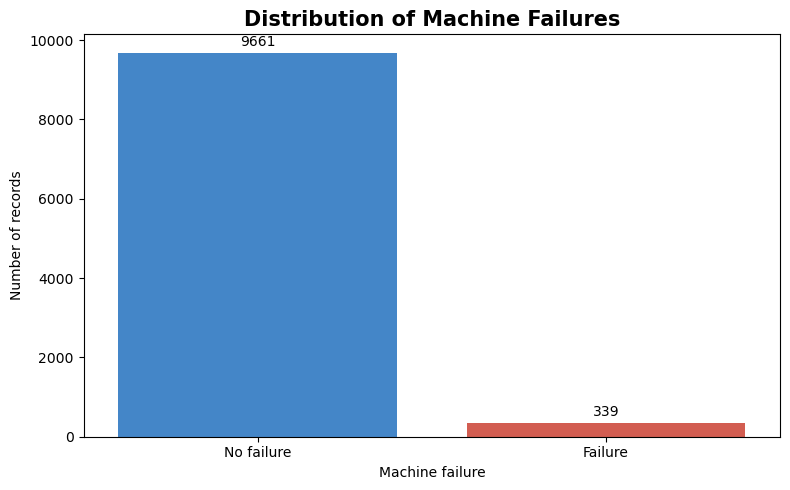

In [28]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x=TARGET,
    palette=["#2E86DE", "#E74C3C"],
)

plt.title(
    "Distribution of Machine Failures",
    fontsize=15,
    fontweight="bold",
)
plt.xlabel("Machine failure")
plt.ylabel("Number of records")
plt.xticks(
    ticks=[0, 1],
    labels=["No failure", "Failure"],
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3,
    )

plt.tight_layout()
plt.show()

In [29]:
model_df = df.rename(
    columns={
        "Type": "product_type",
        "Air temperature [K]": "air_temperature",
        "Process temperature [K]": (
            "process_temperature"
        ),
        "Rotational speed [rpm]": (
            "rotational_speed"
        ),
        "Torque [Nm]": "torque",
        "Tool wear [min]": "tool_wear",
        "Machine failure": "machine_failure",
    }
).copy()

In [30]:
columns_to_drop = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

model_df = model_df.drop(
    columns=columns_to_drop
)

print("Modelling columns:")
print(model_df.columns.tolist())

display(model_df.head())

Modelling columns:
['product_type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure']


,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [31]:
model_df["temperature_difference"] = (
    model_df["process_temperature"]
    - model_df["air_temperature"]
)

In [34]:
model_df["mechanical_power"] = (
    model_df["torque"]
    * model_df["rotational_speed"]
    * (2 * np.pi / 60)
)

In [33]:
import numpy as np

In [35]:
model_df["tool_stress"] = (
    model_df["torque"]
    * model_df["tool_wear"]
)

In [36]:
model_df["temperature_ratio"] = (
    model_df["process_temperature"]
    / model_df["air_temperature"]
)


In [37]:
model_df["torque_speed_ratio"] = (
    model_df["torque"]
    / model_df["rotational_speed"]
)

In [38]:
print(
    "Modelling dataset shape:",
    model_df.shape,
)

print("\nFinal modelling columns:")

for column in model_df.columns:
    print(f"- {column}")

display(model_df.head())

Modelling dataset shape: (10000, 12)

Final modelling columns:
- product_type
- air_temperature
- process_temperature
- rotational_speed
- torque
- tool_wear
- machine_failure
- temperature_difference
- mechanical_power
- tool_stress
- temperature_ratio
- torque_speed_ratio


,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,machine_failure,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,0.0,1.035223,0.027595
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,138.9,1.035211,0.032884
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,247.0,1.034888,0.032977
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,276.5,1.034876,0.027565
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,360.0,1.035211,0.028409


In [39]:
display(
    model_df.describe(
        include="all"
    ).T
)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_temperature,10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
process_temperature,10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
rotational_speed,10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
torque,10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
tool_wear,10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
machine_failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
temperature_difference,10000.0,NaN,NaN,NaN,10.00063,1.001094,7.6,9.3,9.8,11.0,12.1
mechanical_power,10000.0,NaN,NaN,NaN,6279.744953,1067.418295,1148.44061,5561.184484,6271.027344,7003.002724,10469.923005
tool_stress,10000.0,NaN,NaN,NaN,4314.66455,2826.567692,0.0,1963.65,4012.95,6279.0,16497.0


In [40]:
type_summary = pd.crosstab(
    model_df["product_type"],
    model_df["machine_failure"],
    margins=True,
)

display(type_summary)

machine_failure,0,1,All
product_type,,,
H,982,21,1003
L,5765,235,6000
M,2914,83,2997
All,9661,339,10000


In [41]:
from sklearn.model_selection import train_test_split

X = model_df.drop(
    columns="machine_failure"
)

y = model_df["machine_failure"]

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print(
    "\nTraining failure rate:",
    f"{y_train.mean() * 100:.2f}%",
)

print(
    "Testing failure rate:",
    f"{y_test.mean() * 100:.2f}%",
)

print(
    "\nTraining failure cases:",
    y_train.sum(),
)

print(
    "Testing failure cases:",
    y_test.sum(),
)

Training features: (8000, 11)
Testing features: (2000, 11)

Training failure rate: 3.39%
Testing failure rate: 3.40%

Training failure cases: 271
Testing failure cases: 68


In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

categorical_features = [
    "product_type",
]

numerical_features = [
    column
    for column in X_train.columns
    if column not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
            ),
            categorical_features,
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features,
        ),
    ],
    remainder="drop",
)

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

print(
    "\nNumber of numerical features:",
    len(numerical_features),
)

Categorical features:
['product_type']

Numerical features:
['air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'temperature_difference', 'mechanical_power', 'tool_stress', 'temperature_ratio', 'torque_speed_ratio']

Number of numerical features: 10


In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(
    X_train,
    y_train,
)

dummy_predictions = dummy_model.predict(
    X_test
)

print("Dummy model classification report:\n")

print(
    classification_report(
        y_test,
        dummy_predictions,
        target_names=[
            "No failure",
            "Failure",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test,
        dummy_predictions,
    )
)

Dummy model classification report:

              precision    recall  f1-score   support

  No failure       0.97      1.00      0.98      1932
     Failure       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000

Confusion matrix:
[[1932    0]
 [  68    0]]


In [44]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

logistic_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor,
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

logistic_model.fit(
    X_train,
    y_train,
)

logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = (
    logistic_model.predict_proba(X_test)[:, 1]
)

print("Balanced Logistic Regression:\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=[
            "No failure",
            "Failure",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test,
        logistic_predictions,
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            logistic_probabilities,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            logistic_probabilities,
        ),
        4,
    ),
)


Balanced Logistic Regression:

              precision    recall  f1-score   support

  No failure       1.00      0.86      0.92      1932
     Failure       0.18      0.88      0.30        68

    accuracy                           0.86      2000
   macro avg       0.59      0.87      0.61      2000
weighted avg       0.97      0.86      0.90      2000

Confusion matrix:
[[1662  270]
 [   8   60]]

ROC-AUC: 0.9386
PR-AUC: 0.419


In [45]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor,
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

random_forest_model.fit(
    X_train,
    y_train,
)

rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

print("Balanced Random Forest:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "No failure",
            "Failure",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test,
        rf_predictions,
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            rf_probabilities,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            rf_probabilities,
        ),
        4,
    ),
)

Balanced Random Forest:

              precision    recall  f1-score   support

  No failure       0.99      1.00      1.00      1932
     Failure       0.96      0.79      0.87        68

    accuracy                           0.99      2000
   macro avg       0.98      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix:
[[1930    2]
 [  14   54]]

ROC-AUC: 0.9726
PR-AUC: 0.881


In [48]:
from xgboost import XGBClassifier

negative_cases = int(
    (y_train == 0).sum()
)

positive_cases = int(
    (y_train == 1).sum()
)

scale_pos_weight = (
    negative_cases / positive_cases
)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 2),
)

xgboost_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

xgboost_model.fit(
    X_train,
    y_train,
)

xgb_predictions = xgboost_model.predict(
    X_test
)

xgb_probabilities = (
    xgboost_model
    .predict_proba(X_test)[:, 1]
)

print("\nBalanced XGBoost:\n")

print(
    classification_report(
        y_test,
        xgb_predictions,
        target_names=[
            "No failure",
            "Failure",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test,
        xgb_predictions,
    )
)

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            xgb_probabilities,
        ),
        4,
    ),
)

print(
    "PR-AUC:",
    round(
        average_precision_score(
            y_test,
            xgb_probabilities,
        ),
        4,
    ),
)

Scale positive weight: 28.52

Balanced XGBoost:

              precision    recall  f1-score   support

  No failure       0.99      0.99      0.99      1932
     Failure       0.80      0.84      0.82        68

    accuracy                           0.99      2000
   macro avg       0.90      0.92      0.91      2000
weighted avg       0.99      0.99      0.99      2000

Confusion matrix:
[[1918   14]
 [  11   57]]

ROC-AUC: 0.9817
PR-AUC: 0.8892


In [47]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 5.0 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

dummy_probabilities = (
    dummy_model.predict_proba(X_test)[:, 1]
)

model_results = []

def add_model_result(
    model_name,
    predictions,
    probabilities,
):
    model_results.append({
        "model": model_name,
        "accuracy": accuracy_score(
            y_test,
            predictions,
        ),
        "failure_precision": precision_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "failure_recall": recall_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "failure_f1": f1_score(
            y_test,
            predictions,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_test,
            probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            probabilities,
        ),
    })

add_model_result(
    "Dummy",
    dummy_predictions,
    dummy_probabilities,
)

add_model_result(
    "Logistic Regression",
    logistic_predictions,
    logistic_probabilities,
)

add_model_result(
    "Random Forest",
    rf_predictions,
    rf_probabilities,
)

add_model_result(
    "XGBoost",
    xgb_predictions,
    xgb_probabilities,
)

model_comparison = (
    pd.DataFrame(model_results)
    .set_index("model")
    .round(4)
)

display(model_comparison)

,accuracy,failure_precision,failure_recall,failure_f1,roc_auc,pr_auc
model,,,,,,
Dummy,0.9660,0.0000,0.0000,0.0000,0.5000,0.0340
Logistic Regression,0.8610,0.1818,0.8824,0.3015,0.9386,0.4190
Random Forest,0.9920,0.9643,0.7941,0.8710,0.9726,0.8810
XGBoost,0.9875,0.8028,0.8382,0.8201,0.9817,0.8892


In [50]:
X_model_train, X_validation, y_model_train, y_validation = (
    train_test_split(
        X_train,
        y_train,
        test_size=0.20,
        random_state=42,
        stratify=y_train,
    )
)

print(
    "Model-training features:",
    X_model_train.shape,
)

print(
    "Validation features:",
    X_validation.shape,
)

print(
    "\nModel-training failures:",
    y_model_train.sum(),
)

print(
    "Validation failures:",
    y_validation.sum(),
)

print(
    "\nModel-training failure rate:",
    f"{y_model_train.mean() * 100:.2f}%",
)

print(
    "Validation failure rate:",
    f"{y_validation.mean() * 100:.2f}%",
)

Model-training features: (6400, 11)
Validation features: (1600, 11)

Model-training failures: 217
Validation failures: 54

Model-training failure rate: 3.39%
Validation failure rate: 3.38%


In [51]:
model_negative_cases = int(
    (y_model_train == 0).sum()
)

model_positive_cases = int(
    (y_model_train == 1).sum()
)

validation_scale_pos_weight = (
    model_negative_cases
    / model_positive_cases
)

xgboost_validation_model = Pipeline(
    steps=[
        (
            "preprocessing",
            preprocessor,
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=4,
                min_child_weight=3,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=(
                    validation_scale_pos_weight
                ),
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

xgboost_validation_model.fit(
    X_model_train,
    y_model_train,
)

validation_probabilities = (
    xgboost_validation_model
    .predict_proba(X_validation)[:, 1]
)

validation_predictions = (
    validation_probabilities >= 0.50
).astype(int)

print(
    "Validation scale positive weight:",
    round(
        validation_scale_pos_weight,
        2,
    ),
)

print("\nDefault threshold results:\n")

print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=[
            "No failure",
            "Failure",
        ],
        zero_division=0,
    )
)

print(
    "Confusion matrix:\n",
    confusion_matrix(
        y_validation,
        validation_predictions,
    ),
)

Validation scale positive weight: 28.49

Default threshold results:

              precision    recall  f1-score   support

  No failure       0.99      0.99      0.99      1546
     Failure       0.84      0.80      0.82        54

    accuracy                           0.99      1600
   macro avg       0.92      0.90      0.91      1600
weighted avg       0.99      0.99      0.99      1600

Confusion matrix:
 [[1538    8]
 [  11   43]]


In [52]:
threshold_results = []

for threshold in np.arange(
    0.10,
    0.91,
    0.05,
):
    threshold_predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        threshold_predictions,
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation,
            threshold_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation,
            threshold_predictions,
            zero_division=0,
        ),
        "f1_score": f1_score(
            y_validation,
            threshold_predictions,
            zero_division=0,
        ),
        "failures_detected": tp,
        "failures_missed": fn,
        "false_alarms": fp,
    })

threshold_table = pd.DataFrame(
    threshold_results
)

display(
    threshold_table.round(3)
)

,threshold,precision,recall,f1_score,failures_detected,failures_missed,false_alarms
0,0.10,0.469,0.833,0.600,45,9,51
1,0.15,0.587,0.815,0.682,44,10,31
2,0.20,0.638,0.815,0.715,44,10,25
3,0.25,0.667,0.815,0.733,44,10,22
4,0.30,0.705,0.796,0.748,43,11,18
5,0.35,0.754,0.796,0.775,43,11,14
6,0.40,0.796,0.796,0.796,43,11,11
7,0.45,0.796,0.796,0.796,43,11,11
8,0.50,0.843,0.796,0.819,43,11,8
9,0.55,0.857,0.778,0.816,42,12,7


In [53]:
from sklearn.metrics import fbeta_score

f2_scores = []

for threshold in threshold_table[
    "threshold"
]:
    threshold_predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)

    f2_scores.append(
        fbeta_score(
            y_validation,
            threshold_predictions,
            beta=2,
            zero_division=0,
        )
    )

threshold_table["f2_score"] = f2_scores

best_threshold_row = (
    threshold_table
    .sort_values(
        [
            "f2_score",
            "f1_score",
        ],
        ascending=False,
    )
    .iloc[0]
)

best_threshold = float(
    best_threshold_row["threshold"]
)

display(
    threshold_table[
        [
            "threshold",
            "precision",
            "recall",
            "f1_score",
            "f2_score",
            "failures_detected",
            "failures_missed",
            "false_alarms",
        ]
    ].round(3)
)

print(
    "Selected threshold:",
    round(best_threshold, 2),
)

,threshold,precision,recall,f1_score,f2_score,failures_detected,failures_missed,false_alarms
0,0.10,0.469,0.833,0.600,0.721,45,9,51
1,0.15,0.587,0.815,0.682,0.756,44,10,31
2,0.20,0.638,0.815,0.715,0.772,44,10,25
3,0.25,0.667,0.815,0.733,0.780,44,10,22
4,0.30,0.705,0.796,0.748,0.776,43,11,18
5,0.35,0.754,0.796,0.775,0.788,43,11,14
6,0.40,0.796,0.796,0.796,0.796,43,11,11
7,0.45,0.796,0.796,0.796,0.796,43,11,11
8,0.50,0.843,0.796,0.819,0.805,43,11,8
9,0.55,0.857,0.778,0.816,0.792,42,12,7


Selected threshold: 0.5


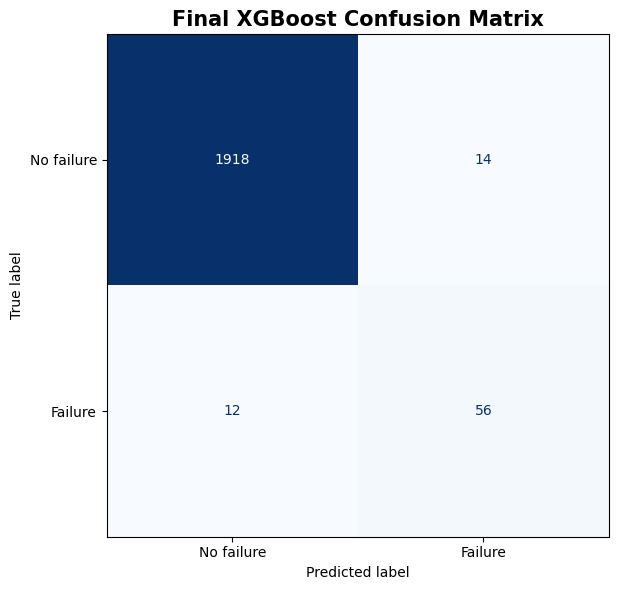

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay

final_threshold = 0.50

final_probabilities = (
    xgboost_model
    .predict_proba(X_test)[:, 1]
)

final_predictions = (
    final_probabilities
    >= final_threshold
).astype(int)

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=[
        "No failure",
        "Failure",
    ],
    cmap="Blues",
    colorbar=False,
    ax=ax,
)

plt.title(
    "Final XGBoost Confusion Matrix",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

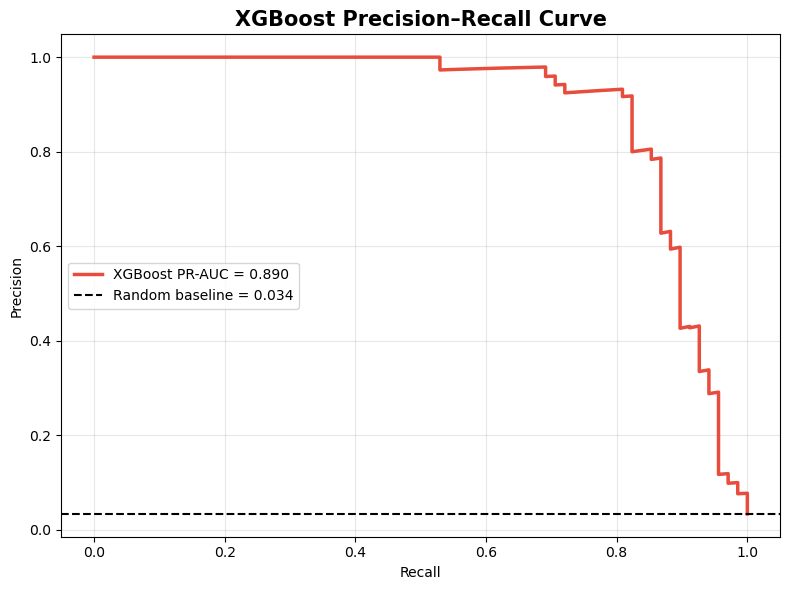

In [55]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
)

precision_values, recall_values, _ = (
    precision_recall_curve(
        y_test,
        final_probabilities,
    )
)

final_pr_auc = average_precision_score(
    y_test,
    final_probabilities,
)

baseline_failure_rate = y_test.mean()

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    color="#E74C3C",
    linewidth=2.5,
    label=(
        f"XGBoost PR-AUC = "
        f"{final_pr_auc:.3f}"
    ),
)

plt.axhline(
    y=baseline_failure_rate,
    color="black",
    linestyle="--",
    label=(
        f"Random baseline = "
        f"{baseline_failure_rate:.3f}"
    ),
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "XGBoost Precision–Recall Curve",
    fontsize=15,
    fontweight="bold",
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
fitted_preprocessor = (
    xgboost_model
    .named_steps["preprocessing"]
)

fitted_xgboost = (
    xgboost_model
    .named_steps["model"]
)

processed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

clean_feature_names = [
    feature_name
    .replace("categorical__", "")
    .replace("numerical__", "")
    for feature_name in processed_feature_names
]

feature_importance = pd.DataFrame({
    "feature": clean_feature_names,
    "importance": (
        fitted_xgboost.feature_importances_
    ),
}).sort_values(
    "importance",
    ascending=False,
)

display(feature_importance)


,feature,importance
8,mechanical_power,0.164663
4,rotational_speed,0.150736
11,torque_speed_ratio,0.148256
6,tool_wear,0.113533
5,torque,0.109914
9,tool_stress,0.087106
7,temperature_difference,0.068229
10,temperature_ratio,0.064203
2,air_temperature,0.029098
0,product_type_L,0.021553


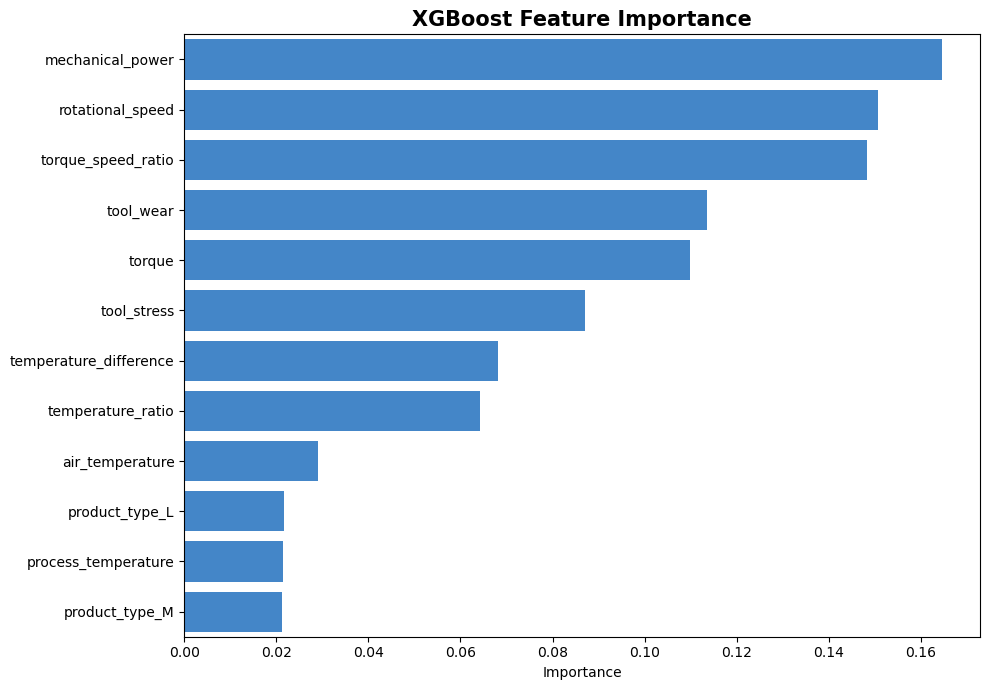

In [57]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature",
    color="#2E86DE",
)

plt.title(
    "XGBoost Feature Importance",
    fontsize=15,
    fontweight="bold",
)

plt.xlabel("Importance")
plt.ylabel("")

plt.tight_layout()
plt.show()

In [60]:
import shap

X_test_processed = (
    fitted_preprocessor
    .transform(X_test)
)

if hasattr(
    X_test_processed,
    "toarray",
):
    X_test_processed = (
        X_test_processed.toarray()
    )

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=clean_feature_names,
    index=X_test.index,
)

shap_explainer = shap.TreeExplainer(
    fitted_xgboost
)

shap_values = shap_explainer(
    X_test_processed_df
)

print(
    "Processed test shape:",
    X_test_processed_df.shape,
)

print(
    "SHAP values shape:",
    shap_values.values.shape,
)

Processed test shape: (2000, 12)
SHAP values shape: (2000, 12)


In [59]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]
Note: you may need to restart the kernel to use updated packages.


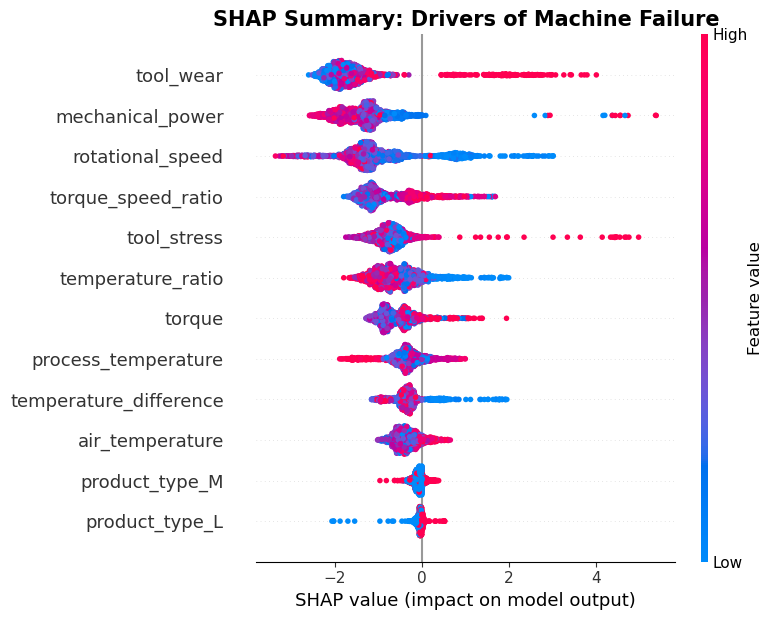

In [61]:
plt.figure(figsize=(11, 8))

shap.plots.beeswarm(
    shap_values,
    max_display=12,
    show=False,
)

plt.title(
    "SHAP Summary: Drivers of Machine Failure",
    fontsize=15,
    fontweight="bold",
)

plt.tight_layout()
plt.show()


In [62]:
highest_risk_position = int(
    np.argmax(final_probabilities)
)

highest_risk_index = (
    X_test.index[
        highest_risk_position
    ]
)

highest_risk_probability = (
    final_probabilities[
        highest_risk_position
    ]
)

highest_risk_actual = int(
    y_test.loc[
        highest_risk_index
    ]
)

print(
    "Test-set index:",
    highest_risk_index,
)

print(
    "Predicted failure probability:",
    f"{highest_risk_probability:.2%}",
)

print(
    "Actual outcome:",
    (
        "Failure"
        if highest_risk_actual == 1
        else "No failure"
    ),
)

display(
    X_test.loc[
        [highest_risk_index]
    ]
)

Test-set index: 4342
Predicted failure probability: 99.99%
Actual outcome: Failure


,product_type,air_temperature,process_temperature,rotational_speed,torque,tool_wear,temperature_difference,mechanical_power,tool_stress,temperature_ratio,torque_speed_ratio
4342,M,301.7,309.8,1284,68.2,111,8.1,9170.183292,7570.2,1.026848,0.053115


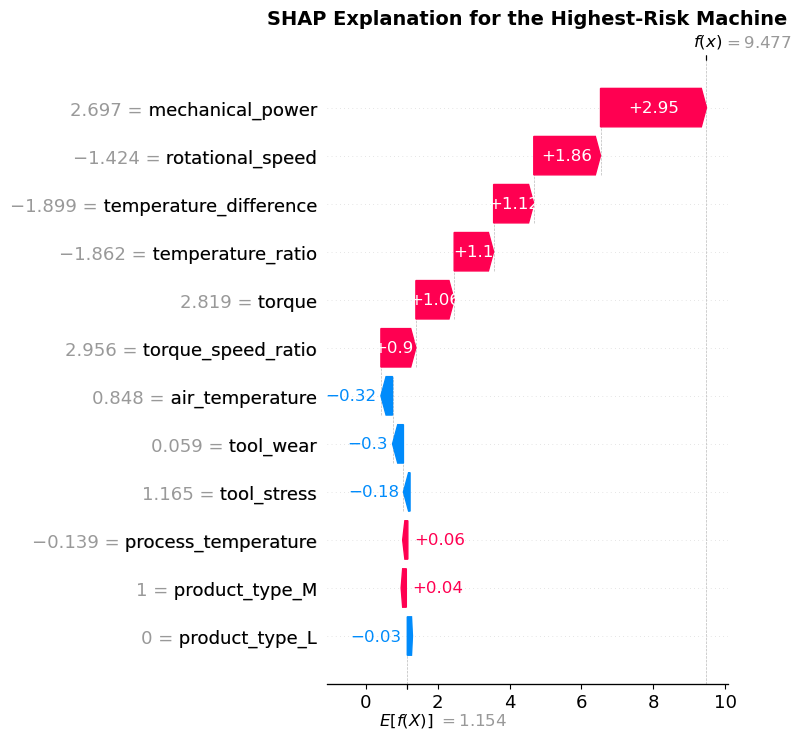

In [63]:
plt.figure(figsize=(10, 7))

shap.plots.waterfall(
    shap_values[
        highest_risk_position
    ],
    max_display=12,
    show=False,
)

plt.title(
    "SHAP Explanation for the Highest-Risk Machine",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

In [65]:
import joblib

model_package = {
    "model": xgboost_model,
    "threshold": final_threshold,
    "raw_features": [
        "product_type",
        "air_temperature",
        "process_temperature",
        "rotational_speed",
        "torque",
        "tool_wear",
    ],
    "model_features": X_train.columns.tolist(),
    "performance": {
        "roc_auc": roc_auc_score(
            y_test,
            final_probabilities,
        ),
        "pr_auc": average_precision_score(
            y_test,
            final_probabilities,
        ),
        "failure_precision": precision_score(
            y_test,
            final_predictions,
        ),
        "failure_recall": recall_score(
            y_test,
            final_predictions,
        ),
        "failure_f1": f1_score(
            y_test,
            final_predictions,
        ),
    },
}

MODEL_PATH = (
    "predictive_maintenance_model.joblib"
)

joblib.dump(
    model_package,
    MODEL_PATH,
)

print(
    "Model saved successfully:",
    MODEL_PATH,
)

print(
    "Selected threshold:",
    model_package["threshold"],
)

print(
    "Saved model features:",
    len(
        model_package["model_features"]
    ),
)

Model saved successfully: predictive_maintenance_model.joblib
Selected threshold: 0.5
Saved model features: 11


In [66]:
from pathlib import Path
import joblib

MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

MODEL_PATH = (
    MODEL_DIR /
    "predictive_maintenance_model.joblib"
)

joblib.dump(
    model_package,
    MODEL_PATH,
)

print(
    "Model saved successfully:",
    MODEL_PATH,
)

Model saved successfully: models/predictive_maintenance_model.joblib
